In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\athar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\athar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [4]:
df = pd.read_json('file.json', lines=True)

print(df.shape)
df.head()

(209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [5]:
print(len(df))
print(df['category'].nunique())
print(df.isnull().sum())

209527
42
link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64


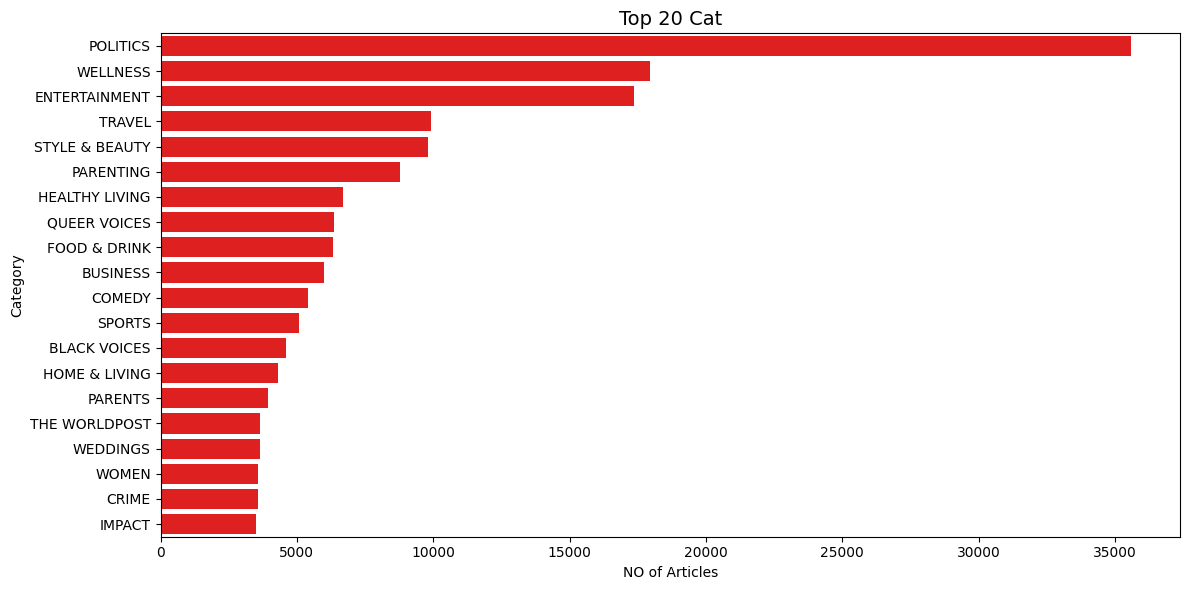

In [6]:
plt.figure(figsize=(12, 6))
category_counts = df['category'].value_counts().head(20)
sns.barplot(x=category_counts.values, y=category_counts.index, color='Red')
plt.title('Top 20 Cat', fontsize=14)
plt.xlabel('NO of Articles')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

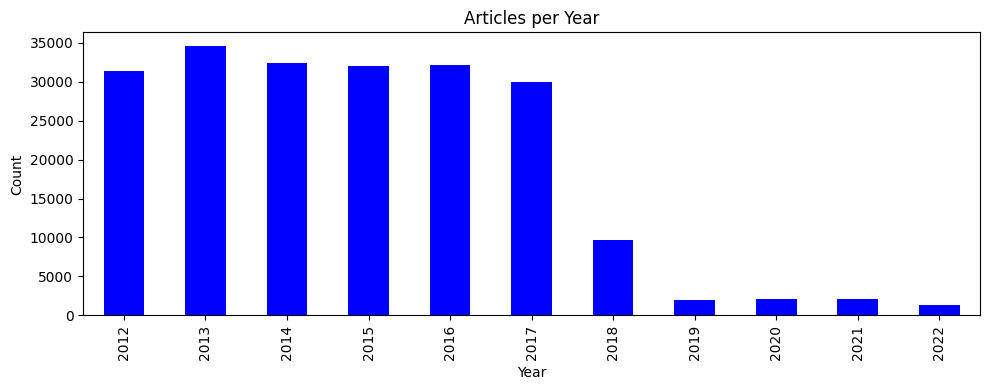

In [7]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
plt.figure(figsize=(10, 4))
df['year'].value_counts().sort_index().plot(kind='bar', color='blue')
plt.title('Articles per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

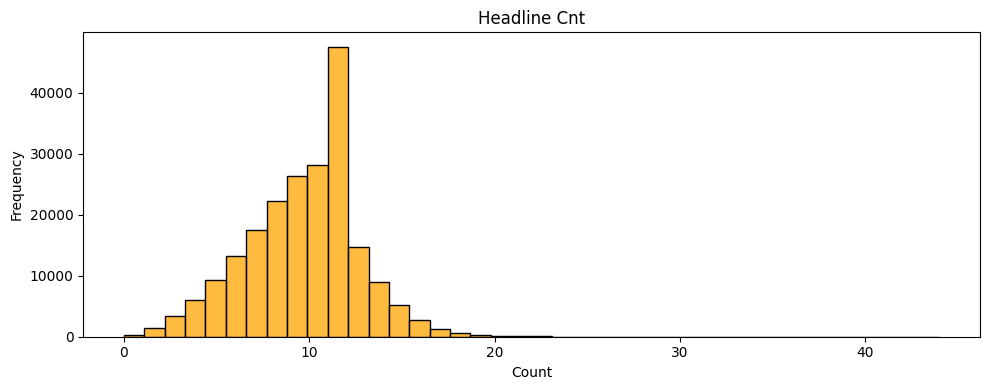

In [8]:
df['headline_length'] = df['headline'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 4))
sns.histplot(df['headline_length'], bins=40, color='orange')
plt.title('Headline Cnt')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [9]:
import re
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()                          
    text = re.sub(r'[^a-z\s]', '', text)            
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text
df['text'] = df['headline'] + ' ' + df['short_description']
df['text'] = df['text'].apply(clean_text)
df = df[df['text'].str.strip() != '']

In [10]:
# Keep only top 10 categories
top10 = df['category'].value_counts().head(10).index
df = df[df['category'].isin(top10)]

print('Categories now:', df['category'].nunique())
print('Records now:', len(df))
print(df['category'].value_counts())

Categories now: 10
Records now: 124779
category
POLITICS          35601
WELLNESS          17945
ENTERTAINMENT     17361
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6690
QUEER VOICES       6346
FOOD & DRINK       6340
BUSINESS           5991
Name: count, dtype: int64


In [11]:
df['text'].iloc[0]

'funniest tweets parents week sept accidentally put grownup toothpaste toddlers toothbrush screamed like cleaning teeth carolina reaper dipped tabasco sauce'

In [12]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),      
    sublinear_tf=True        
)
X = tfidf.fit_transform(df['text'])
y = df['category']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
# Will us navive bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

In [15]:
round(nb_acc * 100, 2)

72.92

In [16]:
# logistic
lr_model = LogisticRegression(max_iter=1000, C=5, solver='lbfgs', multi_class='multinomial')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
round(lr_acc * 100, 2)

80.44

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)

In [18]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
y_pred_knn = knn.predict(X_test)

In [20]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.09520756531495432


In [21]:
print(classification_report(y_test, y_pred_knn))

                precision    recall  f1-score   support

      BUSINESS       0.27      0.03      0.05      1198
 ENTERTAINMENT       0.89      0.11      0.19      3472
  FOOD & DRINK       0.82      0.03      0.05      1268
HEALTHY LIVING       0.06      0.99      0.11      1338
     PARENTING       0.94      0.02      0.03      1758
      POLITICS       0.97      0.02      0.05      7121
  QUEER VOICES       0.96      0.05      0.10      1269
STYLE & BEAUTY       0.99      0.12      0.21      1963
        TRAVEL       0.91      0.01      0.02      1980
      WELLNESS       0.95      0.03      0.05      3589

      accuracy                           0.10     24956
     macro avg       0.78      0.14      0.09     24956
  weighted avg       0.86      0.10      0.08     24956



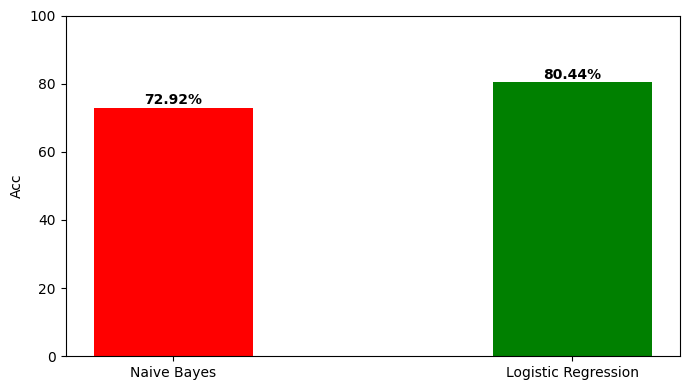

In [22]:
models = ['Naive Bayes', 'Logistic Regression']
scores = [nb_acc * 100, lr_acc * 100]
plt.figure(figsize=(7, 4))
bars = plt.bar(models, scores, color=['red', 'green'], width=0.4)
plt.ylim(0, 100)
plt.ylabel('Acc')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{score:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
print(classification_report(y_test, lr_pred))

                precision    recall  f1-score   support

      BUSINESS       0.72      0.58      0.64      1198
 ENTERTAINMENT       0.83      0.86      0.85      3472
  FOOD & DRINK       0.82      0.80      0.81      1268
HEALTHY LIVING       0.44      0.28      0.35      1338
     PARENTING       0.79      0.73      0.76      1758
      POLITICS       0.88      0.93      0.90      7121
  QUEER VOICES       0.87      0.71      0.78      1269
STYLE & BEAUTY       0.88      0.87      0.88      1963
        TRAVEL       0.84      0.82      0.83      1980
      WELLNESS       0.68      0.80      0.73      3589

      accuracy                           0.80     24956
     macro avg       0.78      0.74      0.75     24956
  weighted avg       0.80      0.80      0.80     24956



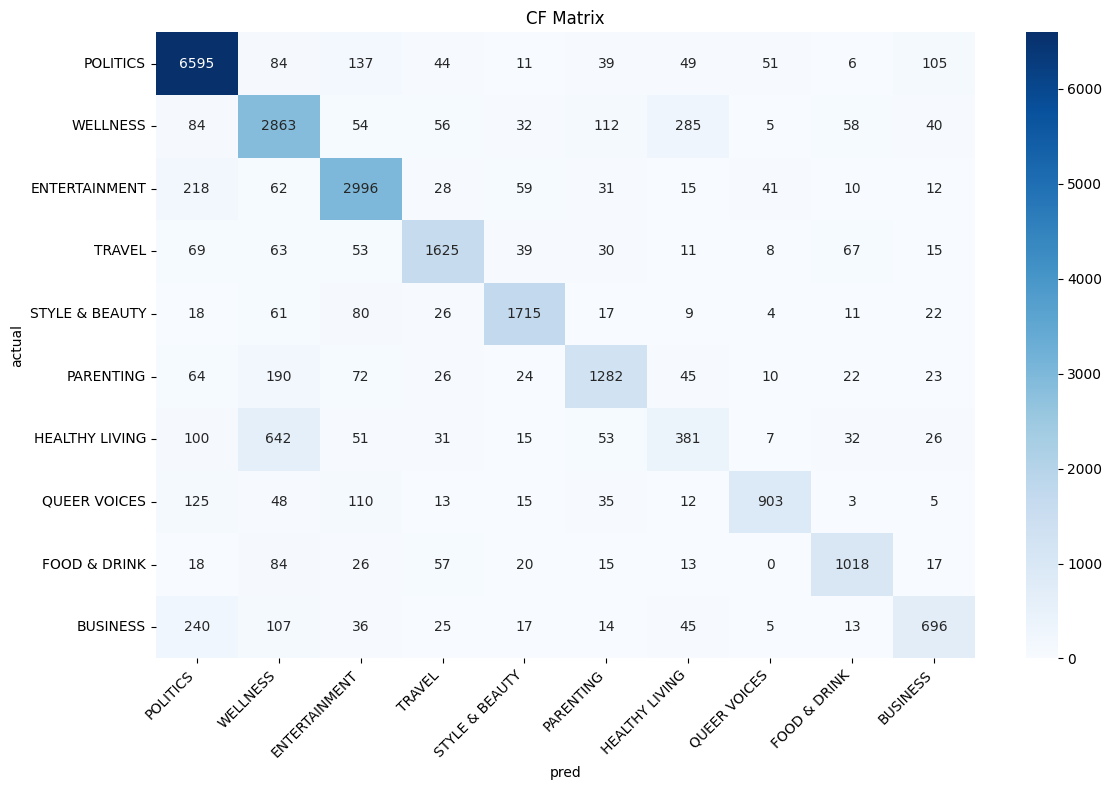

In [24]:
# CF matrix
top10_cats = df['category'].value_counts().head(10).index.tolist()
mask = y_test.isin(top10_cats)
cm = confusion_matrix(y_test[mask], lr_pred[mask], labels=top10_cats)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top10_cats, yticklabels=top10_cats)
plt.title('CF Matrix')
plt.xlabel('pred')
plt.ylabel('actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'
df['sentiment'] = df['headline'].apply(get_sentiment)
df['sentiment'].value_counts()

sentiment
Neutral     49275
Positive    42211
Negative    33293
Name: count, dtype: int64

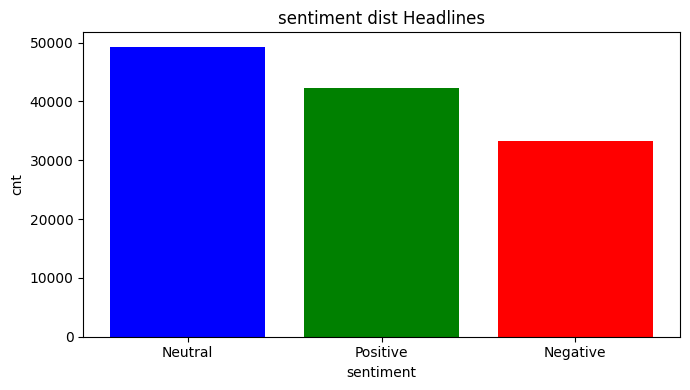

In [26]:
plt.figure(figsize=(7, 4))
colors = {
    'Positive': 'green',
    'Neutral': 'blue',
    'Negative': 'red'
}
sentiment_counts = df['sentiment'].value_counts()
plt.bar(sentiment_counts.index,
        sentiment_counts.values,
        color=[colors[s] for s in sentiment_counts.index])
plt.title('sentiment dist Headlines')
plt.xlabel('sentiment')
plt.ylabel('cnt')
plt.tight_layout()
plt.show()

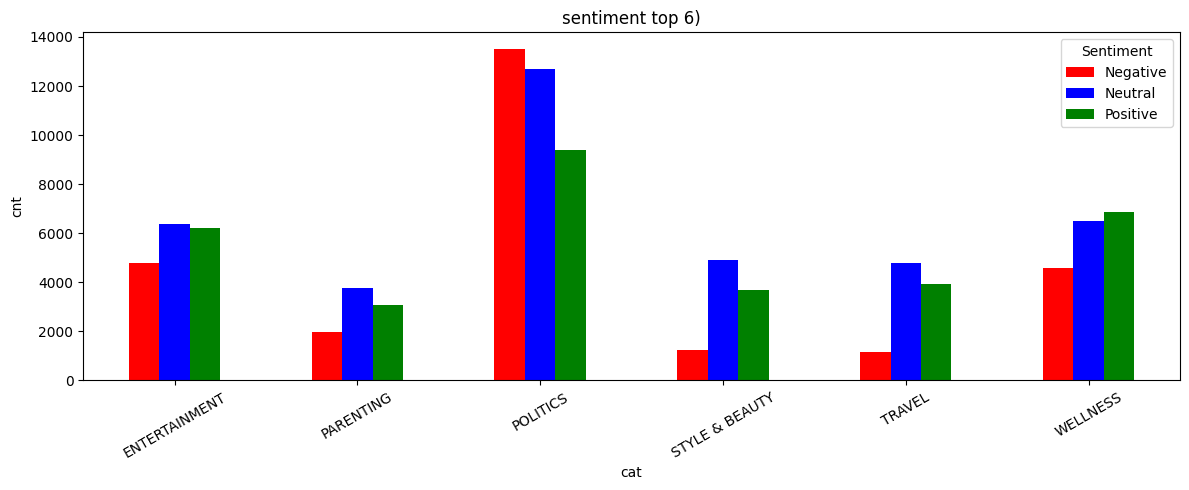

In [27]:
top6 = df['category'].value_counts().head(6).index
df_top6 = df[df['category'].isin(top6)]
sentiment_cat = df_top6.groupby(['category', 'sentiment']).size().unstack(fill_value=0)
sentiment_cat.plot(kind='bar', figsize=(12, 5),
                   color=['red', 'blue', 'green'])
plt.title('sentiment top 6)')
plt.xlabel('cat')
plt.ylabel('cnt')
plt.xticks(rotation=30)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

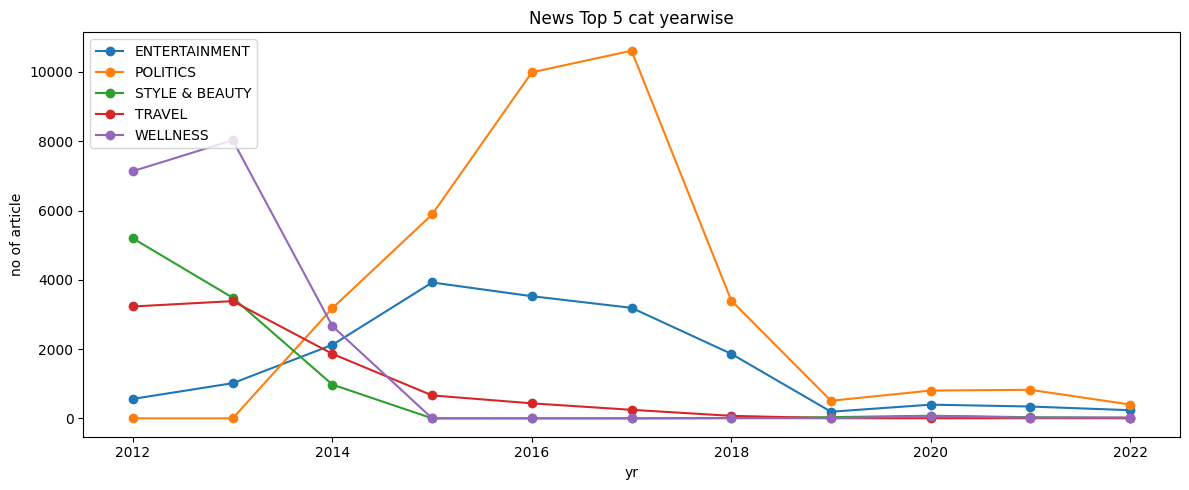

In [28]:
top5 = df['category'].value_counts().head(5).index
df_trend = df[df['category'].isin(top5)]
trend = df_trend.groupby(['year', 'category']).size().unstack(fill_value=0)
plt.figure(figsize=(12, 5))
for col in trend.columns:
    plt.plot(trend.index, trend[col], marker='o', label=col)
plt.title('News Top 5 cat yearwise')
plt.xlabel('yr')
plt.ylabel('no of article')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
import pickle
with open('news_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)